In [1]:
!pip install cdsapi cartopy --quiet

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import pandas as pd

print("All libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 83.3 MB/s eta 0:00:00
All libraries loaded.


In [5]:
ds = xr.open_dataset("/content/era5_monthly_reanalysis_1950_2024_total_prep.nc")
print(ds)
print("\nVariables:", list(ds.data_vars))
print("Time range:", ds.valid_time.values[0], "→", ds.valid_time.values[-1])

<xarray.Dataset> Size: 147MB
Dimensions:     (valid_time: 900, latitude: 169, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01T06:00:00 ... 2024-...
  * latitude    (latitude) float64 1kB 72.0 71.75 71.5 71.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 2kB -15.0 -14.75 -14.5 ... 44.5 44.75 45.0
    number      int64 8B ...
    expver      (valid_time) <U4 14kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 147MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-01T09:40 GRIB to CDM+CF via cfgrib-0.9.1...

Variables: ['tp']
Time range: 1950-01-01T06:00:00.000000000 → 2024-12-01T06:00:00.000000000


In [6]:
# tp is in metres, convert to mm
ds["tp_mm"] = ds["tp"] * 1000

# Quick sanity check — annual mean precipitation
annual_mean = ds["tp_mm"].groupby("valid_time.year").sum("valid_time").mean("year")

print("Precipitation stats (mm/year):")
print(f"  Min: {float(annual_mean.min()):.1f} mm")
print(f"  Max: {float(annual_mean.max()):.1f} mm")
print(f"  Mean: {float(annual_mean.mean()):.1f} mm")

Precipitation stats (mm/year):
  Min: 0.5 mm
  Max: 108.1 mm
  Mean: 24.5 mm


In [7]:
# Check raw tp values
print("Raw tp stats (before conversion):")
print(f"  Min: {float(ds['tp'].min()):.6f}")
print(f"  Max: {float(ds['tp'].max()):.6f}")
print(f"  Mean: {float(ds['tp'].mean()):.6f}")

# Check one specific location — London, January 1990
london = ds["tp"].sel(
    latitude=51.5, longitude=-0.1,
    method="nearest"
).sel(valid_time="1990-01-01T06:00:00", method="nearest")
print(f"\nLondon Jan 1990 raw: {float(london):.6f} m")
print(f"London Jan 1990 mm: {float(london)*1000:.2f} mm")

Raw tp stats (before conversion):
  Min: 0.000000
  Max: 0.032465
  Mean: 0.001866

London Jan 1990 raw: 0.002037 m
London Jan 1990 mm: 2.04 mm


In [8]:
# Get days in each month for proper scaling

times = pd.DatetimeIndex(ds["valid_time"].values)
days_in_month = times.days_in_month.values  # array of days per month

# Multiply each time step by days in that month
tp_monthly = ds["tp"] * 1000 * days_in_month[:, np.newaxis, np.newaxis]
ds["tp_mm"] = xr.DataArray(
    tp_monthly,
    coords=ds["tp"].coords,
    dims=ds["tp"].dims
)

# Recheck London
london = ds["tp_mm"].sel(
    latitude=51.5, longitude=-0.1,
    method="nearest"
).sel(valid_time="1990-01-01T06:00:00", method="nearest")
print(f"London Jan 1990: {float(london):.1f} mm")

# Annual check
annual_mean = ds["tp_mm"].groupby("valid_time.year").sum("valid_time").mean("year")
print(f"\nAnnual mean: {float(annual_mean.mean()):.1f} mm/year")
print(f"Max: {float(annual_mean.max()):.1f} mm/year")
print(f"Min: {float(annual_mean.min()):.1f} mm/year")

London Jan 1990: 63.1 mm

Annual mean: 745.6 mm/year
Max: 3298.2 mm/year
Min: 16.1 mm/year


In [9]:
# Annual total precipitation per grid cell
annual_tp = ds["tp_mm"].groupby("valid_time.year").sum("valid_time")
# Shape: (75, 169, 241)

years = np.arange(1950, 2025)
n_lat, n_lon = len(ds.latitude), len(ds.longitude)

trend_tp = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        slope, _, _, _, _ = stats.linregress(years, annual_tp.values[:, i, j])
        trend_tp[i, j] = slope  # mm per year

print(f"Trend range: {trend_tp.min():.2f} to {trend_tp.max():.2f} mm/year")
print(f"Mean trend: {trend_tp.mean():.2f} mm/year")
print("Done!")

Trend range: -5.06 to 10.09 mm/year
Mean trend: 0.52 mm/year
Done!


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


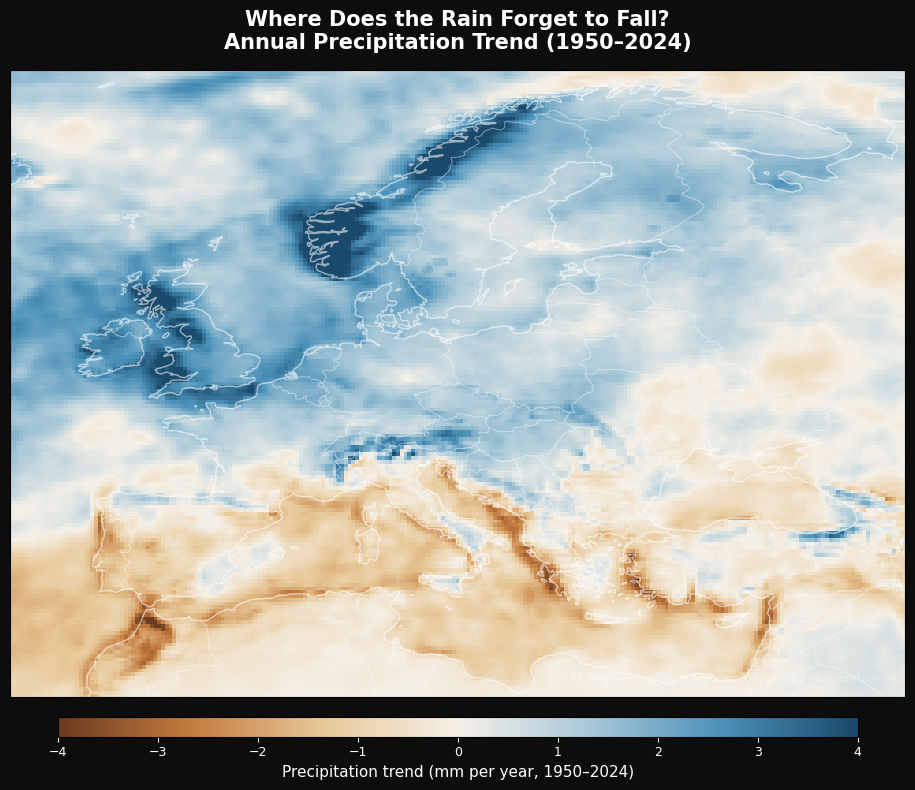

Saved!


In [15]:
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

# Diverging: drying brown → neutral → wetting blue
colors = ["#6b3a1f", "#c47c3e", "#e8c99a", "#f5f0e8", "#a8c8d8", "#4a90b8", "#1a4a6b"]
cmap = LinearSegmentedColormap.from_list("precip_trend", colors)
ax.set_extent([-15, 45, 30, 72], crs=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds.longitude, ds.latitude, trend_tp,
    cmap=cmap, vmin=-4, vmax=4,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
ax.add_feature(cfeature.BORDERS, linewidth=0.7, color="#ffffff70")
ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="none", zorder=0)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                    pad=0.03, fraction=0.03, aspect=40)
cbar.set_label("Precipitation trend (mm per year, 1950–2024)",
               color="white", fontsize=11)
cbar.ax.xaxis.set_tick_params(color="white")
plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=9)

ax.set_title("Where Does the Rain Forget to Fall?\nAnnual Precipitation Trend (1950–2024)",
             color="white", fontsize=15, fontweight="bold", pad=15)

ax.text(0.99, 0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 04",
        transform=ax.transAxes, color="#ffffff60",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig("exploration_04_precip_trend.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

In [11]:
# Separate into seasons
# Autumn: Oct, Nov, Dec — traditional Mediterranean rain season
# Spring: Mar, Apr, May — shifted rain season?

autumn_months = [10, 11, 12]
spring_months = [3, 4, 5]

# Annual autumn and spring totals
autumn_tp = ds["tp_mm"].sel(
    valid_time=ds["valid_time"].dt.month.isin(autumn_months)
).groupby("valid_time.year").sum("valid_time")

spring_tp = ds["tp_mm"].sel(
    valid_time=ds["valid_time"].dt.month.isin(spring_months)
).groupby("valid_time.year").sum("valid_time")

print(f"Autumn shape: {autumn_tp.shape}")
print(f"Spring shape: {spring_tp.shape}")

# Compute trends
trend_autumn = np.full((n_lat, n_lon), np.nan)
trend_spring = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        slope_a, _, _, _, _ = stats.linregress(years, autumn_tp.values[:, i, j])
        slope_s, _, _, _, _ = stats.linregress(years, spring_tp.values[:, i, j])
        trend_autumn[i, j] = slope_a
        trend_spring[i, j] = slope_s

print(f"\nAutumn trend: {trend_autumn.min():.2f} to {trend_autumn.max():.2f} mm/year")
print(f"Spring trend: {trend_spring.min():.2f} to {trend_spring.max():.2f} mm/year")
print("Done!")

Autumn shape: (75, 169, 241)
Spring shape: (75, 169, 241)

Autumn trend: -2.76 to 2.68 mm/year
Spring trend: -1.75 to 2.43 mm/year
Done!


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazo

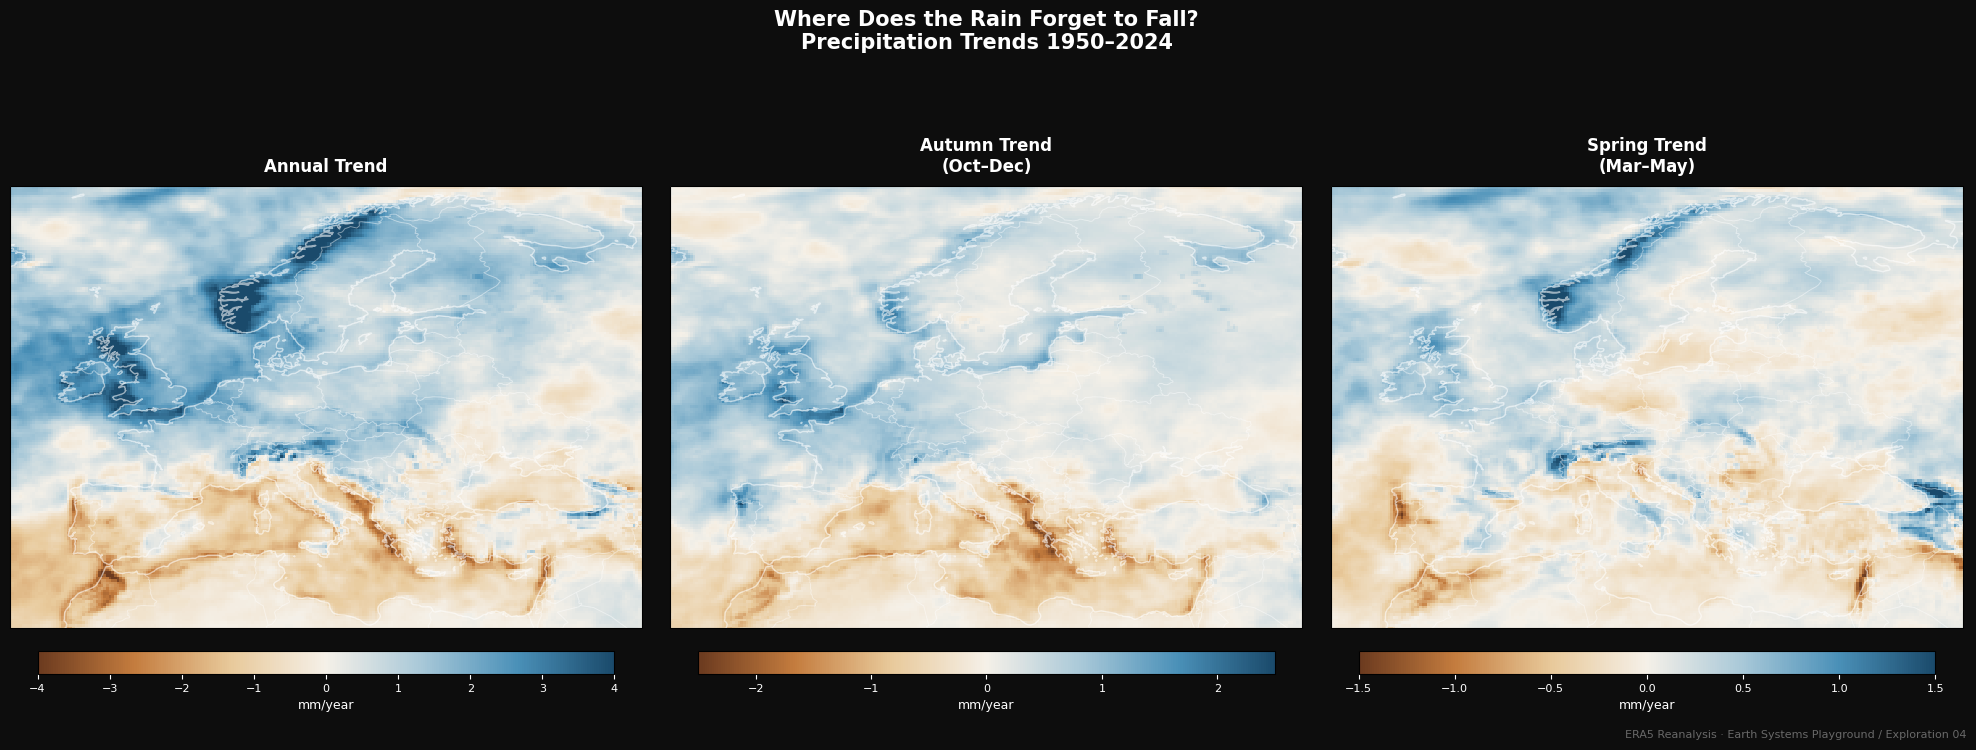

Saved!


In [14]:
fig, axes = plt.subplots(
    1, 3, figsize=(20, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")

titles = [
    "Annual Trend",
    "Autumn Trend\n(Oct–Dec)",
    "Spring Trend\n(Mar–May)"
]
data = [trend_tp, trend_autumn, trend_spring]
vmins = [-4, -2.5, -1.5]
vmaxs = [4, 2.5, 1.5]

colors = ["#6b3a1f", "#c47c3e", "#e8c99a", "#f5f0e8", "#a8c8d8", "#4a90b8", "#1a4a6b"]
cmap = LinearSegmentedColormap.from_list("precip_trend", colors)

for ax, title, d, vmin, vmax in zip(axes, titles, data, vmins, vmaxs):
    ax.set_facecolor("#0d0d0d")

    ax.set_extent([-15, 45, 30, 72], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds.longitude, ds.latitude, d,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="none", zorder=0)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.04, aspect=25)
    cbar.set_label("mm/year", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Where Does the Rain Forget to Fall?\nPrecipitation Trends 1950–2024",
    color="white", fontsize=15, fontweight="bold", y=1.02
)

fig.text(0.99, -0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 04",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("exploration_04_seasonal.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazo

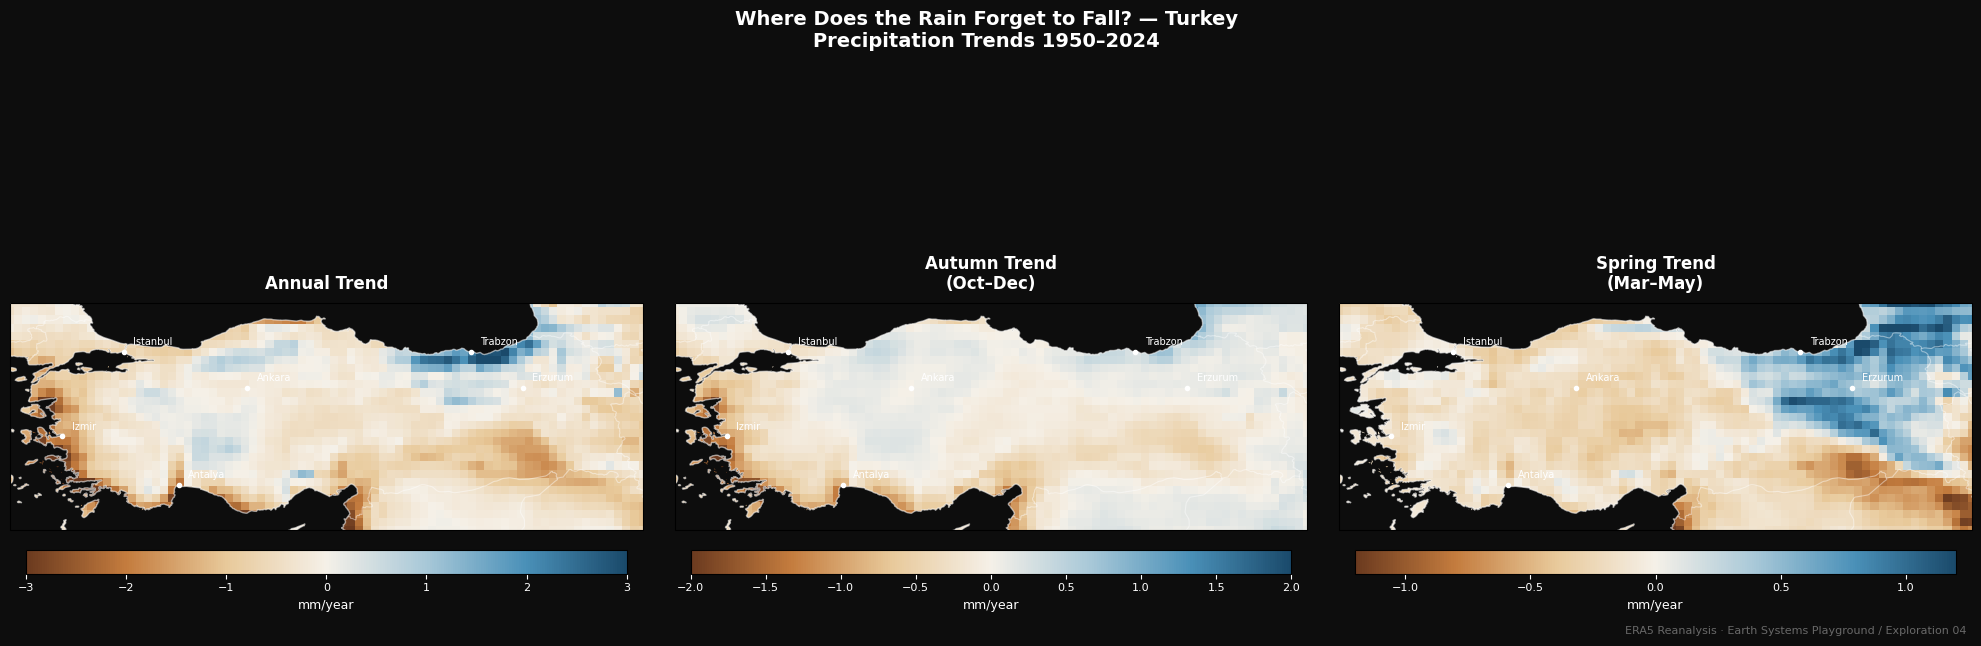

Saved!


In [16]:
# Turkey bounding box
tr_lat_min, tr_lat_max = 35.5, 42.5
tr_lon_min, tr_lon_max = 25.5, 45.0

fig, axes = plt.subplots(
    1, 3, figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")

titles = [
    "Annual Trend",
    "Autumn Trend\n(Oct–Dec)",
    "Spring Trend\n(Mar–May)"
]
data = [trend_tp, trend_autumn, trend_spring]
vmins = [-3, -2, -1.2]
vmaxs = [3, 2, 1.2]

for ax, title, d, vmin, vmax in zip(axes, titles, data, vmins, vmaxs):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent([tr_lon_min, tr_lon_max, tr_lat_min, tr_lat_max],
                  crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds.longitude, ds.latitude, d,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    # Add city markers
    cities_tr = {
        "Istanbul":  (41.0, 29.0),
        "Ankara":    (39.9, 32.8),
        "Izmir":     (38.4, 27.1),
        "Antalya":   (36.9, 30.7),
        "Erzurum":   (39.9, 41.3),
        "Trabzon":   (41.0, 39.7),
    }

    for city, (lat, lon) in cities_tr.items():
        ax.plot(lon, lat, "o", color="white",
                markersize=3, transform=ccrs.PlateCarree(), zorder=5)
        ax.text(lon + 0.3, lat + 0.2, city, color="white",
                fontsize=7, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(title, color="white", fontsize=12,
                 fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("mm/year", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Where Does the Rain Forget to Fall? — Turkey\nPrecipitation Trends 1950–2024",
    color="white", fontsize=14, fontweight="bold", y=1.02
)

fig.text(0.99, -0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 04",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("exploration_04_turkey_zoom.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

In [17]:
# Two city groups
cities_exp01 = {
    "Istanbul":  {"lat": 41.0, "lon": 29.0},
    "Paris":     {"lat": 48.8, "lon": 2.3},
    "Madrid":    {"lat": 40.4, "lon": -3.7},
    "Berlin":    {"lat": 52.5, "lon": 13.4},
    "London":    {"lat": 51.5, "lon": -0.1},
}

cities_turkey = {
    "Istanbul":  {"lat": 41.0, "lon": 29.0},
    "Ankara":    {"lat": 39.9, "lon": 32.8},
    "Izmir":     {"lat": 38.4, "lon": 27.1},
    "Antalya":   {"lat": 36.9, "lon": 30.7},
    "Trabzon":   {"lat": 41.0, "lon": 39.7},
    "Erzurum":   {"lat": 39.9, "lon": 41.3},
}

colors_exp01 = {
    "Istanbul": "#e74c3c",
    "Paris":    "#3498db",
    "Madrid":   "#f39c12",
    "Berlin":   "#2ecc71",
    "London":   "#9b59b6",
}

colors_turkey = {
    "Istanbul": "#e74c3c",
    "Ankara":   "#f39c12",
    "Izmir":    "#3498db",
    "Antalya":  "#2ecc71",
    "Trabzon":  "#9b59b6",
    "Erzurum":  "#e67e22",
}

# Annual totals per city
years = np.arange(1950, 2025)

def get_city_annual(ds, cities):
    result = {}
    for city, coords in cities.items():
        ts_monthly = ds["tp_mm"].sel(
            latitude=coords["lat"],
            longitude=coords["lon"],
            method="nearest"
        )
        ts_annual = ts_monthly.groupby("valid_time.year").sum("valid_time").values
        result[city] = ts_annual
    return result

data_exp01 = get_city_annual(ds, cities_exp01)
data_turkey = get_city_annual(ds, cities_turkey)

print("City data extracted!")
for city, vals in data_turkey.items():
    print(f"  {city}: mean {vals.mean():.0f} mm/year")

City data extracted!
  Istanbul: mean 750 mm/year
  Ankara: mean 465 mm/year
  Izmir: mean 713 mm/year
  Antalya: mean 1125 mm/year
  Trabzon: mean 1805 mm/year
  Erzurum: mean 689 mm/year


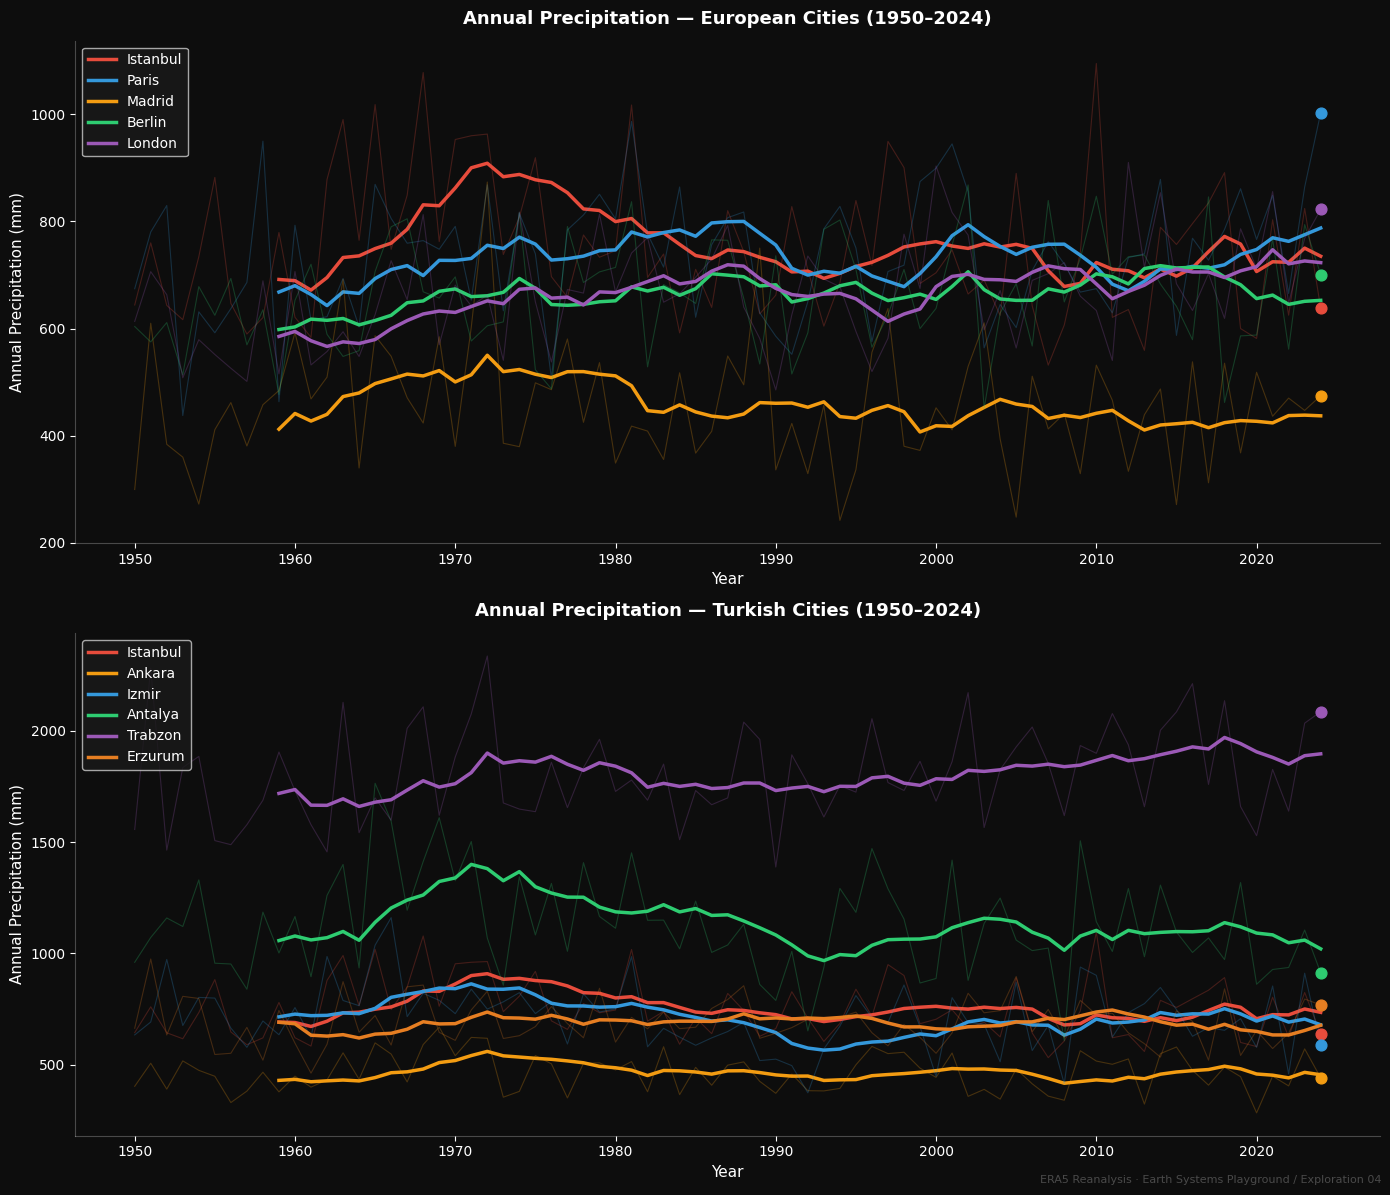

Saved!


In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.patch.set_facecolor("#0d0d0d")

for ax, city_data, city_colors, title in zip(
    [ax1, ax2],
    [data_exp01, data_turkey],
    [colors_exp01, colors_turkey],
    ["Annual Precipitation — European Cities (1950–2024)",
     "Annual Precipitation — Turkish Cities (1950–2024)"]
):
    ax.set_facecolor("#0d0d0d")

    for city, ts in city_data.items():
        # Raw
        ax.plot(years, ts, color=city_colors[city],
                alpha=0.25, linewidth=0.8)
        # Smoothed
        smoothed = np.convolve(ts, np.ones(10)/10, mode="valid")
        ax.plot(years[9:], smoothed, color=city_colors[city],
                linewidth=2.5, label=city)
        # 2024 dot
        ax.scatter(2024, ts[-1], color=city_colors[city],
                   s=60, zorder=5)

    ax.set_xlabel("Year", color="white", fontsize=11)
    ax.set_ylabel("Annual Precipitation (mm)", color="white", fontsize=11)
    ax.set_title(title, color="white", fontsize=13,
                 fontweight="bold", pad=12)
    ax.tick_params(colors="white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#ffffff40")
    ax.legend(facecolor="#1a1a1a", labelcolor="white",
              framealpha=0.8, fontsize=10)

fig.text(0.99, 0.01,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 04",
         color="#ffffff40", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("exploration_04_cities.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

In [19]:
# Rolling 15-year standard deviation trend
# For each grid cell: compute std of annual precip in 15-year windows
# Then trend of that std over time

window = 15
n_windows = len(years) - window + 1
window_years = years[window//2: window//2 + n_windows]  # center of each window

variability = np.full((n_windows, n_lat, n_lon), np.nan)

annual_tp_vals = annual_tp.values  # shape (75, 169, 241)

for w in range(n_windows):
    variability[w] = annual_tp_vals[w:w+window].std(axis=0)

# Trend of variability over time
trend_var = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        slope, _, _, _, _ = stats.linregress(window_years, variability[:, i, j])
        trend_var[i, j] = slope  # mm/year increase in std per year

print(f"Variability trend range: {trend_var.min():.3f} to {trend_var.max():.3f} mm/year²")
print(f"Mean: {trend_var.mean():.3f}")
print("Done!")

Variability trend range: -3.376 to 2.826 mm/year²
Mean: -0.091
Done!


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


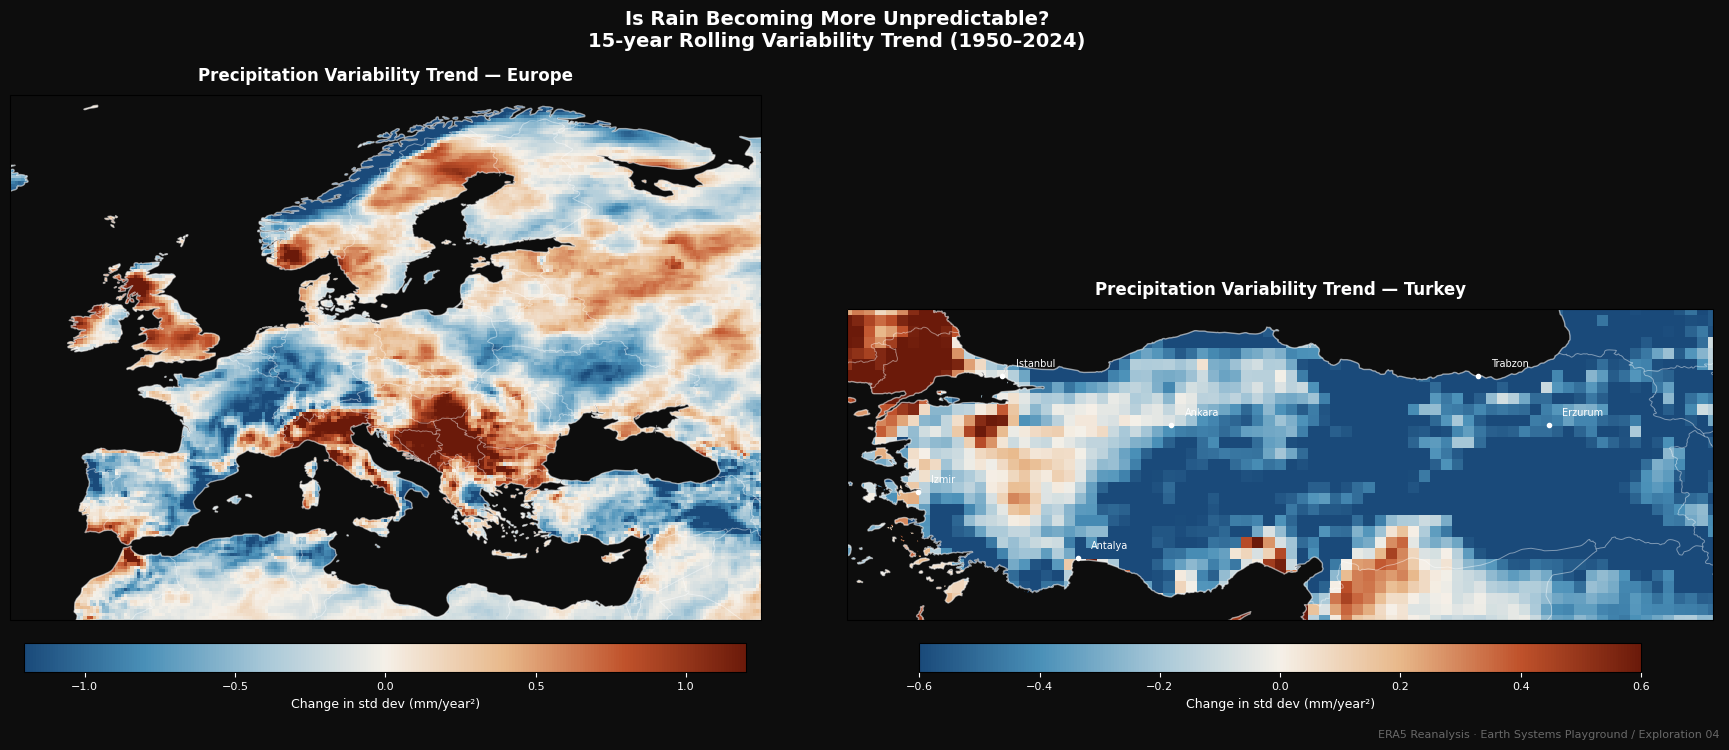

Saved!


In [20]:
fig, axes = plt.subplots(
    1, 2, figsize=(18, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")

# Colormap: stable blue → neutral → chaotic red/orange
colors_var = ["#1a4a7a", "#4a90b8", "#a8c8d8", "#f5f0e8", "#e8b88a", "#c0522b", "#6b1a0a"]
cmap_var = LinearSegmentedColormap.from_list("variability", colors_var)

panels = [
    (trend_var, "Europe", [-15, 45, 30, 72], 1.2),
    (trend_var, "Turkey", [25.5, 45.0, 35.5, 42.5], 0.6),
]

for ax, (d, title, extent, vlim) in zip(axes, panels):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds.longitude, ds.latitude, d,
        cmap=cmap_var, vmin=-vlim, vmax=vlim,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    if title == "Turkey":
        for city, (lat, lon) in cities_tr.items():
            ax.plot(lon, lat, "o", color="white",
                    markersize=3, transform=ccrs.PlateCarree(), zorder=5)
            ax.text(lon + 0.3, lat + 0.2, city, color="white",
                    fontsize=7, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(f"Precipitation Variability Trend — {title}",
                 color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("Change in std dev (mm/year²)", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Is Rain Becoming More Unpredictable?\n15-year Rolling Variability Trend (1950–2024)",
    color="white", fontsize=14, fontweight="bold", y=1.02
)

fig.text(0.99, -0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 04",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("exploration_04_variability.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")